# Análisis exploratorio de BD Dengue

In [133]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [134]:
# Cargar BD
df_total = pd.read_excel(r"C:\Users\usuario1\OneDrive - Universidad de Antioquia\UNIVERSIDAD DE ANTIOQUIA\Proyecto SAT Dengue\Bases de datos\Secretaria de salud\BD_DENGUE_2021-2025.xlsx")
df_total.head()

,cod_eve,fec_not,ini_sin_,semana,año,cod_pre,cod_sub,edad_,uni_med_,nacionali_,...,nom_upgd,npais_proce,ndep_proce,nmun_proce,npais_resi,ndep_resi,nmun_resi,ndep_notif,nmun_notif,nreg
0,210,2021-01-11,2021-01-07,1,2021,515402201,1,40,1,170,...,ESE HOSPITAL CESAR URIBE PIEDRAHITA,COLOMBIA,ANTIOQUIA,EL BAGRE,COLOMBIA,ANTIOQUIA,EL BAGRE,ANTIOQUIA,CAUCASIA,1800
1,210,2021-02-16,2021-01-21,3,2021,526605568,10,38,1,170,...,SIN INFORMACIÓN,COLOMBIA,ANTIOQUIA,CAUCASIA,COLOMBIA,ANTIOQUIA,ENVIGADO,SIN INFORMACIÓN,SIN INFORMACIÓN,1793
2,210,2021-02-06,2021-02-01,5,2021,515402201,1,12,1,170,...,ESE HOSPITAL CESAR URIBE PIEDRAHITA,COLOMBIA,ANTIOQUIA,ZARAGOZA,COLOMBIA,ANTIOQUIA,ZARAGOZA,ANTIOQUIA,CAUCASIA,1791
3,210,2021-02-19,2021-02-08,6,2021,526605568,10,54,1,170,...,SIN INFORMACIÓN,COLOMBIA,ANTIOQUIA,CAUCASIA,COLOMBIA,BOGOTA,BOGOTA,SIN INFORMACIÓN,SIN INFORMACIÓN,1795
4,210,2021-02-12,2021-02-10,6,2021,2548885069,80,25,1,170,...,SIN INFORMACIÓN,COLOMBIA,CUNDINAMARCA,NILO,COLOMBIA,ANTIOQUIA,CAUCASIA,SIN INFORMACIÓN,SIN INFORMACIÓN,1798


In [135]:
# Revisar valores nulos
df_total.isnull().sum()

cod_eve       0
fec_not       0
ini_sin_      0
semana        0
año           0
             ..
ndep_resi     0
nmun_resi     0
ndep_notif    0
nmun_notif    0
nreg          0
Length: 120, dtype: int64

In [136]:
df_caucasia = pd.read_excel(r"C:\Users\usuario1\OneDrive - Universidad de Antioquia\UNIVERSIDAD DE ANTIOQUIA\Proyecto SAT Dengue\Bases de datos\Secretaria de salud\BD_DENGUE_2021-2025_CAUCASIA.xlsx")
df_caucasia.head()

PermissionError: [Errno 13] Permission denied: 'C:\\Users\\usuario1\\OneDrive - Universidad de Antioquia\\UNIVERSIDAD DE ANTIOQUIA\\Proyecto SAT Dengue\\Bases de datos\\Secretaria de salud\\BD_DENGUE_2021-2025_CAUCASIA.xlsx'

In [ ]:
# Ver estructura de la base de datos
df_caucasia.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6117 entries, 0 to 6116
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   ini_sin_    6117 non-null   datetime64[ns]
 1   semana      6117 non-null   int64         
 2   año         6117 non-null   int64         
 3   area_       6117 non-null   int64         
 4   localidad_  6117 non-null   object        
 5   cen_pobla_  6117 non-null   object        
 6   vereda_     6117 non-null   object        
 7   bar_ver_    6117 non-null   object        
 8   dir_res_    6117 non-null   object        
 9   nmun_proce  6117 non-null   object        
 10  nmun_resi   6117 non-null   object        
dtypes: datetime64[ns](1), int64(3), object(7)
memory usage: 525.8+ KB


In [ ]:
# Revisar valores nulos
df_caucasia.isnull().sum()

ini_sin_      0
semana        0
año           0
area_         0
localidad_    0
cen_pobla_    0
vereda_       0
bar_ver_      0
dir_res_      0
nmun_proce    0
nmun_resi     0
dtype: int64

In [ ]:
# Convertir la columna 'ini_sin_' a formato de fecha
df_caucasia['ini_sin_'] = pd.to_datetime(df_caucasia['ini_sin_'], errors='coerce')

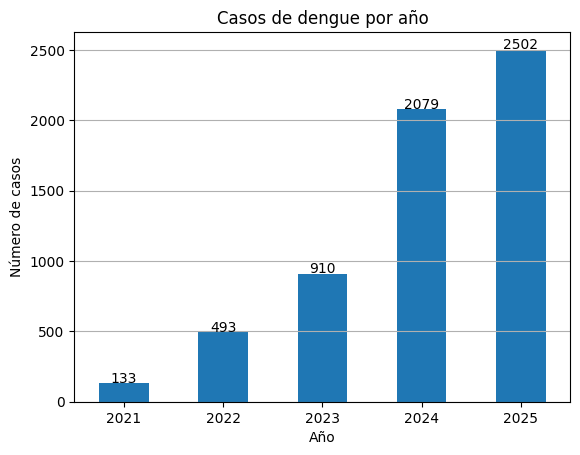

In [ ]:
# Casos por año
casos_año = df_caucasia['año'].value_counts().sort_index()

plt.figure()

ax = casos_año.plot(kind='bar')

plt.title("Casos de dengue por año")
plt.xlabel("Año")
plt.ylabel("Número de casos")
plt.xticks(rotation=0)
plt.grid(axis='y')

# Mostrar valores sobre cada barra
for i, v in enumerate(casos_año):
    ax.text(i, v + 5, str(v), ha='center')

plt.show()

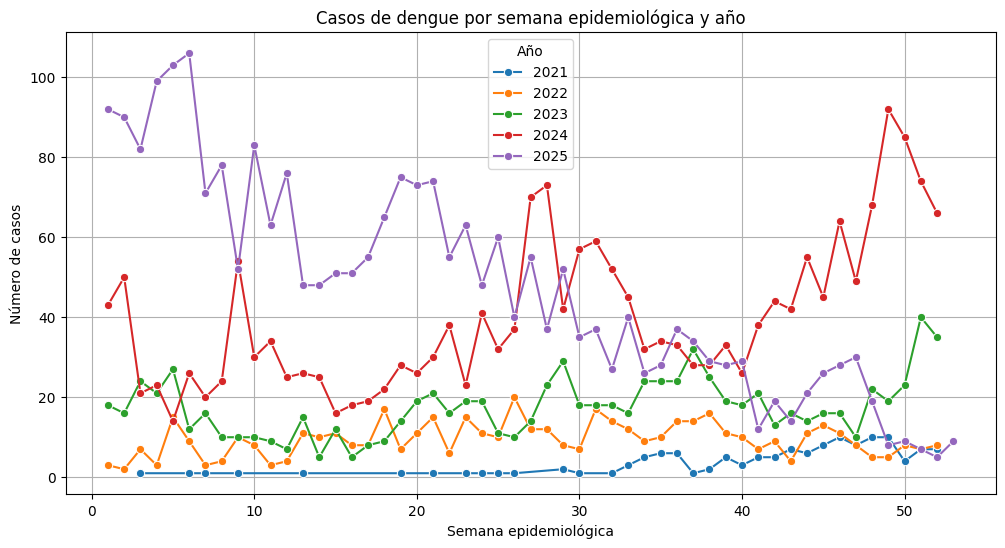

In [ ]:
# Casos por semana epidemiológica por año
plt.figure(figsize=(12, 6))
casos_semana = df_caucasia.groupby(['año', 'semana']).size().reset_index(name='num_casos')

sns.lineplot(
    data=casos_semana,
    x='semana',
    y='num_casos',
    hue='año',
    marker='o',
    palette='tab10'  # Colores más contrastantes
)

plt.title("Casos de dengue por semana epidemiológica y año")
plt.xlabel("Semana epidemiológica")
plt.ylabel("Número de casos")
plt.legend(title='Año')
plt.grid()
plt.show()


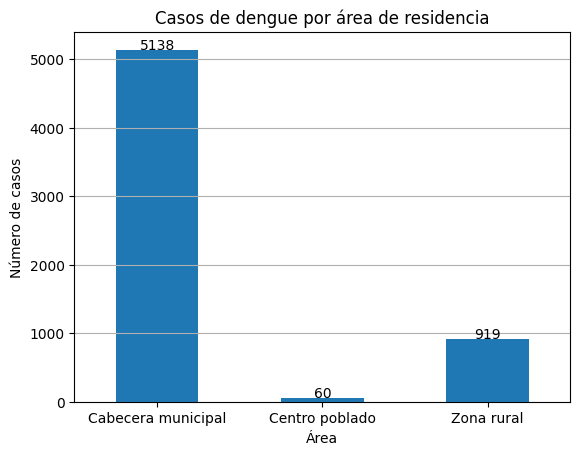

In [ ]:
# Analizar casos por área
casos_area = df_caucasia['area_'].value_counts().sort_index()

# Reemplazar códigos por nombres
casos_area.index = ['Cabecera municipal', 'Centro poblado', 'Zona rural']

plt.figure()

ax = casos_area.plot(kind='bar')

plt.title("Casos de dengue por área de residencia")
plt.xlabel("Área")
plt.ylabel("Número de casos")
plt.xticks(rotation=0)
plt.grid(axis='y')

# Mostrar número de casos sobre cada barra
for i, v in enumerate(casos_area):
    ax.text(i, v + 5, str(v), ha='center')

plt.show()

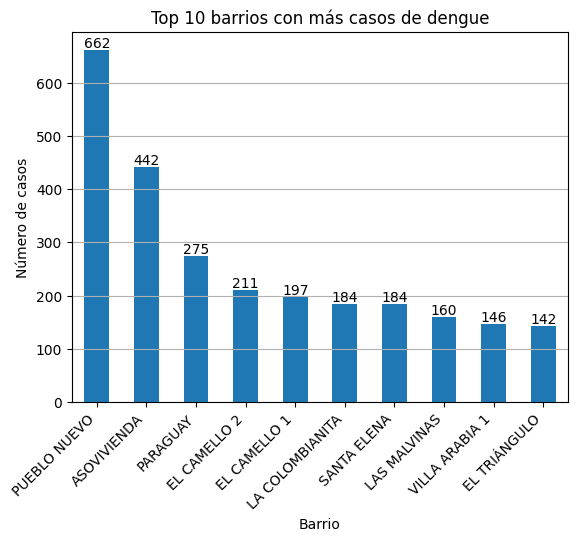

In [ ]:
barrios = df_caucasia['bar_ver_'].value_counts().head(10)

plt.figure()

barrios.plot(kind='bar')

plt.title("Top 10 barrios con más casos de dengue")
plt.xlabel("Barrio")
plt.ylabel("Número de casos")

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')

# Mostrar número de casos sobre cada barra
for i, v in enumerate(barrios):
    plt.text(i, v + 5, str(v), ha='center')

plt.show()

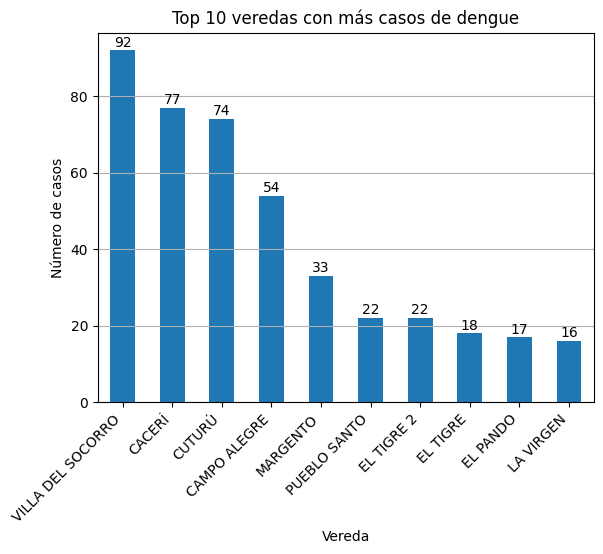

In [ ]:
# Veredas con más casos excluyendo "no aplica"
veredas = df_caucasia[df_caucasia['vereda_'] != 'NO APLICA']['vereda_'].value_counts().head(10) 
plt.figure()
veredas.plot(kind='bar')
plt.title("Top 10 veredas con más casos de dengue")
plt.xlabel("Vereda")
plt.ylabel("Número de casos")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
for i, v in enumerate(veredas):
    plt.text(i, v + 1, str(v), ha='center')
plt.show()

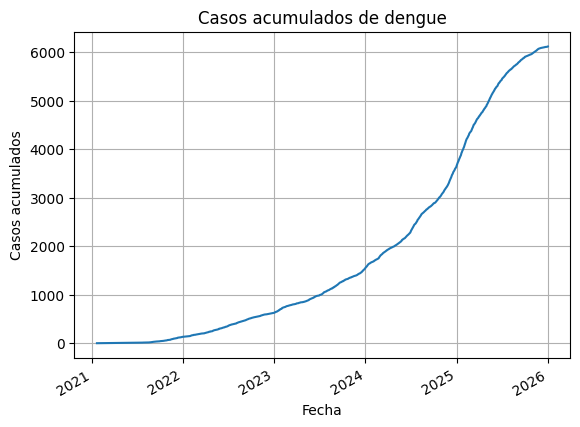

In [ ]:
# Casos acumulados por fecha de notificación
casos_fecha = df_caucasia.groupby('ini_sin_').size()

casos_acumulados = casos_fecha.cumsum()

plt.figure()

casos_acumulados.plot()

plt.title("Casos acumulados de dengue")

plt.xlabel("Fecha")

plt.ylabel("Casos acumulados")
plt.grid()

plt.show()

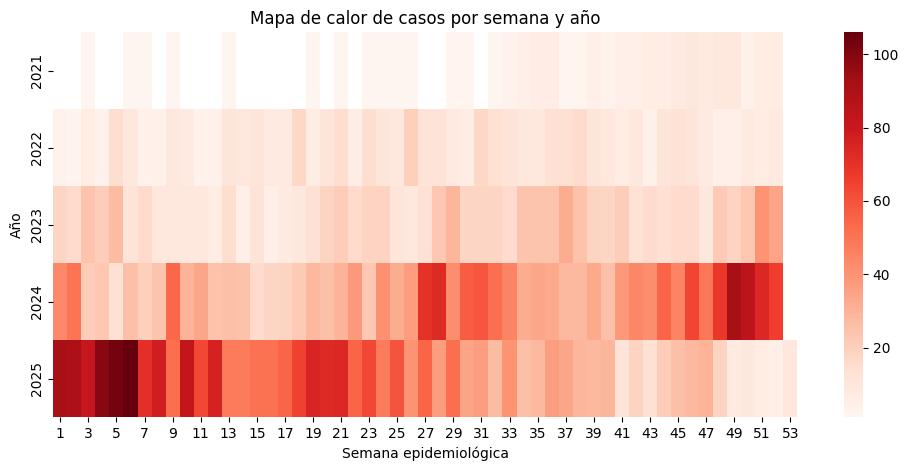

In [ ]:
# Heatmap de semanas por año
tabla = df_caucasia.groupby(['año','semana']).size().unstack()

plt.figure(figsize=(12,5))

sns.heatmap(tabla, cmap="Reds")

plt.title("Mapa de calor de casos por semana y año")

plt.xlabel("Semana epidemiológica")

plt.ylabel("Año")

plt.show()

# Reemuestreo

In [154]:
# ---------------------------
# 1. AGRUPAR CASOS POR SEMANA REAL
# ---------------------------
df_epi = df_caucasia.copy()

df_semanal = df_epi.groupby(['año', 'semana']).size().reset_index(name='num_casos')


# ---------------------------
# 2. ESTRUCTURA 2021–2024 (52 semanas)
# ---------------------------
estructura_1 = pd.MultiIndex.from_product(
    [range(2021, 2025), range(1, 53)],
    names=['año', 'semana']
).to_frame(index=False)

df_1_epi = pd.merge(estructura_1, df_semanal, on=['año', 'semana'], how='left')
df_1_epi['num_casos'] = df_1_epi['num_casos'].fillna(0).astype(int)


# ---------------------------
# 3. ESTRUCTURA 2025 (53 semanas)
# ---------------------------
estructura_2 = pd.DataFrame({
    'año': [2025]*53,
    'semana': range(1, 54)
})

df_2_epi = pd.merge(estructura_2, df_semanal, on=['año', 'semana'], how='left')
df_2_epi['num_casos'] = df_2_epi['num_casos'].fillna(0).astype(int)


# ---------------------------
# 4. FECHAS CORRECTAS (CLAVE)
# ---------------------------
inicios = {
    2021: '2021-01-03',
    2022: '2022-01-02',
    2023: '2023-01-01',
    2024: '2023-12-31',  # ← corrige el error de 25 vs 22 dic
    2025: '2024-12-29'
}

def asignar_fecha(row):
    inicio = pd.Timestamp(inicios[row['año']])
    return inicio + pd.to_timedelta((row['semana'] - 1) * 7, unit='D')


# Aplicar
df_1_epi['fecha'] = df_1_epi.apply(asignar_fecha, axis=1)
df_2_epi['fecha'] = df_2_epi.apply(asignar_fecha, axis=1)


# ---------------------------
# 5. UNIR TODO
# ---------------------------
df_final_epi = pd.concat([df_1_epi, df_2_epi])

df_final_epi = df_final_epi.sort_values('fecha').set_index('fecha')
df_final_epi = df_final_epi.rename(columns={'semana': 'semana_epi'})

In [142]:
df_1_epi

,año,semana,num_casos,fecha
0,2021,1,0,2021-01-03
1,2021,2,0,2021-01-10
2,2021,3,1,2021-01-17
3,2021,4,0,2021-01-24
4,2021,5,0,2021-01-31
...,...,...,...,...
203,2024,48,68,2024-11-24
204,2024,49,92,2024-12-01
205,2024,50,85,2024-12-08
206,2024,51,74,2024-12-15


In [144]:
df_2_epi

,año,semana,num_casos,fecha
0,2025,1,92,2024-12-29
1,2025,2,90,2025-01-05
2,2025,3,82,2025-01-12
3,2025,4,99,2025-01-19
4,2025,5,103,2025-01-26
5,2025,6,106,2025-02-02
6,2025,7,71,2025-02-09
7,2025,8,78,2025-02-16
8,2025,9,52,2025-02-23
9,2025,10,83,2025-03-02


# Datos meteorológicos

In [155]:
df_meteo_caucasia = pd.read_excel(r"C:\Users\usuario1\OneDrive - Universidad de Antioquia\UNIVERSIDAD DE ANTIOQUIA\Proyecto SAT Dengue\Bases de datos\Datos meteorológicos\Datos_NS_2021-2025.xlsx")
df_meteo_caucasia.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,QV2M,RH2M,PRECTOTCORR,WS2M,WS2M_MAX,WS2M_MIN,ALLSKY_SFC_UV_INDEX
0,2021,3,28.64,35.09,23.84,17.89,75.41,4.03,0.14,0.32,0.07,2.48
1,2021,4,28.48,35.05,23.69,15.91,68.69,0.70,0.14,0.25,0.07,2.47
2,2021,5,27.84,34.96,22.71,15.16,68.47,0.62,0.16,0.34,0.03,2.30
3,2021,6,28.58,35.31,23.50,15.64,67.09,0.00,0.11,0.22,0.04,2.34
4,2021,7,28.52,34.44,23.73,15.94,67.92,0.04,0.11,0.22,0.05,2.03


In [156]:
# Renombrar columnas del dataframe nasa
df_meteo_caucasia.rename(columns={
    'YEAR': 'año',
    'DOY': 'dia',
    'T2M': 'temp',
    'T2M_MAX': 'temp_max',
    'T2M_MIN': 'temp_min',
    'QV2M': 'hum_esp',
    'RH2M': 'hum_rel',
    'PRECTOTCORR': 'prec',
    'WS2M': 'vel_vi',
    'WS2M_MAX': 'vel_vi_max',
    'WS2M_MIN': 'vel_vi_min',
    'ALLSKY_SFC_UV_INDEX': 'uv'
}, inplace=True)
df_meteo_caucasia.head(3)

,año,dia,temp,temp_max,temp_min,hum_esp,hum_rel,prec,vel_vi,vel_vi_max,vel_vi_min,uv
0,2021,3,28.64,35.09,23.84,17.89,75.41,4.03,0.14,0.32,0.07,2.48
1,2021,4,28.48,35.05,23.69,15.91,68.69,0.70,0.14,0.25,0.07,2.47
2,2021,5,27.84,34.96,22.71,15.16,68.47,0.62,0.16,0.34,0.03,2.30


In [157]:
df_meteo_caucasia.columns

Index(['año', 'dia', 'temp', 'temp_max', 'temp_min', 'hum_esp', 'hum_rel',
       'prec', 'vel_vi', 'vel_vi_max', 'vel_vi_min', 'uv'],
      dtype='object')

In [158]:
df_meteo = df_meteo_caucasia.copy()

# Crear fecha real
df_meteo['fecha'] = pd.to_datetime(df_meteo['año'].astype(str) + '-' + df_meteo['dia'].astype(str), format='%Y-%j')

In [159]:
df_meteo['dias_lluvia'] = (df_meteo['prec'] >= 1).astype(int)

In [160]:
inicios = {
    2021: pd.Timestamp('2021-01-03'),
    2022: pd.Timestamp('2022-01-02'),
    2023: pd.Timestamp('2023-01-01'),
    2024: pd.Timestamp('2023-12-31'),
    2025: pd.Timestamp('2024-12-29')
}

def asignar_semana(row):
    año = row['fecha'].year
    
    # Ajuste especial para fechas que pertenecen a semana epi del siguiente año
    if row['fecha'] >= inicios[2025]:
        año = 2025
    elif row['fecha'] >= inicios[2024]:
        año = 2024
    elif row['fecha'] >= inicios[2023]:
        año = 2023
    elif row['fecha'] >= inicios[2022]:
        año = 2022
    else:
        año = 2021

    semana = ((row['fecha'] - inicios[año]).days // 7) + 1
    return pd.Series([año, semana])

df_meteo[['año_epi', 'semana']] = df_meteo.apply(asignar_semana, axis=1)

In [161]:
df_semanal = df_meteo.groupby(['año_epi', 'semana']).agg({
    'temp': 'mean',
    'temp_max': 'mean',
    'temp_min': 'mean',
    'hum_esp': 'mean',
    'hum_rel': 'mean',
    'prec': 'mean',
    'dias_lluvia': 'sum',
    'vel_vi': 'mean',
    'vel_vi_max': 'mean',
    'vel_vi_min': 'mean',
    'uv': 'mean',
    'prec': 'sum',
}).reset_index()

df_semanal = df_semanal.rename(columns={'año_epi': 'año'})

In [162]:
estructura_1 = pd.MultiIndex.from_product(
    [range(2021, 2025), range(1, 53)],
    names=['año', 'semana']
).to_frame(index=False)

df_1_meteo = pd.merge(estructura_1, df_semanal, on=['año', 'semana'], how='left')


In [163]:
estructura_2 = pd.DataFrame({
    'año': [2025]*53,
    'semana': range(1, 54)
})

df_2_meteo = pd.merge(estructura_2, df_semanal, on=['año', 'semana'], how='left')

In [164]:
def asignar_fecha(row):
    inicio = inicios[row['año']]
    return inicio + pd.to_timedelta((row['semana'] - 1) * 7, unit='D')

df_1_meteo['fecha'] = df_1_meteo.apply(asignar_fecha, axis=1)
df_2_meteo['fecha'] = df_2_meteo.apply(asignar_fecha, axis=1)

In [167]:
df_final_meteo = pd.concat([df_1_meteo, df_2_meteo])
df_final_meteo = df_final_meteo.sort_values('fecha').set_index('fecha')

In [165]:
df_1_meteo

,año,semana,temp,temp_max,temp_min,hum_esp,hum_rel,prec,dias_lluvia,vel_vi,vel_vi_max,vel_vi_min,uv,fecha
0,2021,1,28.252857,34.200000,23.832857,16.308571,70.508571,5.72,1,0.121429,0.244286,0.047143,2.222857,2021-01-03
1,2021,2,28.687143,34.910000,24.195714,17.318571,72.885714,19.15,5,0.117143,0.208571,0.038571,2.254286,2021-01-10
2,2021,3,29.592857,36.372857,24.090000,16.112857,65.122857,0.77,0,0.124286,0.225714,0.045714,2.420000,2021-01-17
3,2021,4,29.190000,35.978571,24.200000,16.511429,68.068571,12.92,4,0.122857,0.220000,0.035714,2.477143,2021-01-24
4,2021,5,29.454286,35.882857,24.684286,17.427143,70.105714,17.94,3,0.120000,0.221429,0.030000,2.290000,2021-01-31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203,2024,48,26.315714,29.455714,24.061429,19.802857,92.042857,42.79,7,0.154286,0.368571,0.040000,1.878571,2024-11-24
204,2024,49,26.521429,29.908571,24.115714,19.595714,90.112857,18.76,3,0.157143,0.357143,0.054286,1.762857,2024-12-01
205,2024,50,26.795714,30.527143,23.571429,19.075714,86.485714,7.92,1,0.194286,0.521429,0.021429,1.921429,2024-12-08
206,2024,51,26.630000,29.824286,24.062857,19.545714,89.310000,10.38,3,0.155714,0.425714,0.021429,1.652857,2024-12-15


In [166]:
df_2_meteo

,año,semana,temp,temp_max,temp_min,hum_esp,hum_rel,prec,dias_lluvia,vel_vi,vel_vi_max,vel_vi_min,uv,fecha
0,2025,1,25.131429,28.048571,23.124286,18.568571,92.692857,72.06,7,0.160000,0.390000,0.030000,1.744286,2024-12-29
1,2025,2,26.591429,30.398571,23.624286,18.684286,86.071429,11.90,2,0.187143,0.467143,0.040000,1.871429,2025-01-05
2,2025,3,26.794286,31.061429,23.178571,18.380000,84.000000,0.71,0,0.180000,0.474286,0.032857,2.080000,2025-01-12
3,2025,4,26.942857,31.498571,23.451429,18.291429,82.930000,2.61,2,0.162857,0.415714,0.008571,1.988571,2025-01-19
4,2025,5,27.131429,31.527143,24.010000,19.011429,84.907143,18.51,1,0.120000,0.242857,0.017143,1.947143,2025-01-26
5,2025,6,27.028571,31.348571,23.721429,18.410000,83.014286,35.14,5,0.135714,0.292857,0.022857,1.775714,2025-02-02
6,2025,7,26.948571,31.570000,23.697143,18.337143,83.350000,26.70,7,0.125714,0.248571,0.024286,1.754286,2025-02-09
7,2025,8,27.531429,32.497143,24.010000,18.410000,81.182857,16.16,6,0.142857,0.280000,0.042857,1.890000,2025-02-16
8,2025,9,27.650000,32.394286,24.411429,18.812857,82.111429,25.09,5,0.134286,0.231429,0.060000,1.805714,2025-02-23
9,2025,10,27.300000,32.092857,24.110000,18.254286,81.497143,23.63,6,0.137143,0.232857,0.060000,1.942857,2025-03-02


# Datos fusionados

In [205]:
# Unir datos
df_final_fusionado = (
    pd.merge(
        df_final_epi.reset_index(),
        df_final_meteo.reset_index().drop(columns=['año', 'semana']),
        on='fecha',
        how='left'
    )
    .rename(columns={'num_casos': 'casos_dengue'})
)

# Quitar hora de la fecha
df_final_fusionado['fecha'] = pd.to_datetime(df_final_fusionado['fecha']).dt.date

# Reordenar columnas
columnas_orden = [
    'fecha',
    'año',
    'semana_epi',
    'casos_dengue',
    'temp', 'temp_max', 'temp_min',
    'hum_esp', 'hum_rel',
    'prec', 'dias_lluvia',
    'vel_vi', 'vel_vi_max', 'vel_vi_min',
    'uv'
]

df_final_fusionado = df_final_fusionado[columnas_orden]

# Guardar
df_final_fusionado.to_excel('df_final_fusionado.xlsx', index=False)

df_final_fusionado.head()

,fecha,año,semana_epi,casos_dengue,temp,temp_max,temp_min,hum_esp,hum_rel,prec,dias_lluvia,vel_vi,vel_vi_max,vel_vi_min,uv
0,2021-01-03,2021,1,0,28.252857,34.200000,23.832857,16.308571,70.508571,5.72,1,0.121429,0.244286,0.047143,2.222857
1,2021-01-10,2021,2,0,28.687143,34.910000,24.195714,17.318571,72.885714,19.15,5,0.117143,0.208571,0.038571,2.254286
2,2021-01-17,2021,3,1,29.592857,36.372857,24.090000,16.112857,65.122857,0.77,0,0.124286,0.225714,0.045714,2.420000
3,2021-01-24,2021,4,0,29.190000,35.978571,24.200000,16.511429,68.068571,12.92,4,0.122857,0.220000,0.035714,2.477143
4,2021-01-31,2021,5,0,29.454286,35.882857,24.684286,17.427143,70.105714,17.94,3,0.120000,0.221429,0.030000,2.290000


In [172]:
# Unir datos epidemiológicos con meteorológicos, indice fecha
df_final_fusionado = (
    pd.merge(
        df_final_epi.reset_index(),
        df_final_meteo.reset_index().drop(columns=['año', 'semana']),
        on='fecha',
        how='left'
    )
    .set_index('fecha')
    .rename(columns={'num_casos': 'casos_dengue'})
)

df_final_fusionado.head()

,año,semana_epi,casos_dengue,temp,temp_max,temp_min,hum_esp,hum_rel,prec,dias_lluvia,vel_vi,vel_vi_max,vel_vi_min,uv
fecha,,,,,,,,,,,,,,
2021-01-03,2021,1,0,28.252857,34.200000,23.832857,16.308571,70.508571,5.72,1,0.121429,0.244286,0.047143,2.222857
2021-01-10,2021,2,0,28.687143,34.910000,24.195714,17.318571,72.885714,19.15,5,0.117143,0.208571,0.038571,2.254286
2021-01-17,2021,3,1,29.592857,36.372857,24.090000,16.112857,65.122857,0.77,0,0.124286,0.225714,0.045714,2.420000
2021-01-24,2021,4,0,29.190000,35.978571,24.200000,16.511429,68.068571,12.92,4,0.122857,0.220000,0.035714,2.477143
2021-01-31,2021,5,0,29.454286,35.882857,24.684286,17.427143,70.105714,17.94,3,0.120000,0.221429,0.030000,2.290000


In [202]:
# Guardar la base de datos fusionada en un nuevo archivo Excel
df_final_fusionado.to_excel(r"C:\Users\usuario1\OneDrive - Universidad de Antioquia\UNIVERSIDAD DE ANTIOQUIA\Proyecto SAT Dengue\Bases de datos\Secretaria de salud\BD_FUSIONADA_DENGUE_2021-2025.xlsx", index=False)


# Prueba de normalidad

In [173]:
from scipy.stats import shapiro

# Seleccionar solo las columnas numéricas
numericas = df_final_meteo.select_dtypes(include=["float64", "int64"]) # esto elimina la fecha de lso atributos a determinar correlacion

# Aplicar Shapiro-Wilk a cada variable
resultados_normalidad = {}
for col in numericas.columns:
    stat, p = shapiro(numericas[col].dropna())
    resultados_normalidad[col] = {"Estadístico W": stat, "Valor p": p}

# Mostrar resultados
df_normalidad = pd.DataFrame(resultados_normalidad).T
df_normalidad["Normal (p>0.05)"] = df_normalidad["Valor p"] > 0.05
df_normalidad

,Estadístico W,Valor p,Normal (p>0.05)
año,0.887037,5.048390e-13,False
semana,0.954090,2.453246e-07,False
temp,0.918075,8.844446e-11,False
temp_max,0.883381,2.935706e-13,False
temp_min,0.982230,2.424447e-03,False
hum_esp,0.948293,5.566736e-08,False
hum_rel,0.830738,3.457162e-16,False
prec,0.890738,8.848779e-13,False
dias_lluvia,0.885627,4.089839e-13,False
vel_vi,0.977408,3.669202e-04,False


In [177]:
# Seleccionar solo las columnas numéricas
df_numerico = df_final_fusionado.select_dtypes(include=['float64', 'int64']) # esto elimina la fecha de lso atributos a determinar correlacion

# Calcular la matriz de correlación de Spearman
corr_spearman = df_numerico.corr(method='spearman')

# Mostrar matriz en consola
print("Matriz de correlación de Spearman:\n")
corr_spearman

Matriz de correlación de Spearman:



,año,semana_epi,casos_dengue,temp,temp_max,temp_min,hum_esp,hum_rel,prec,dias_lluvia,vel_vi,vel_vi_max,vel_vi_min,uv
año,1.000000,0.009351,0.845035,-0.295848,-0.320738,-0.100687,0.476392,0.413751,0.304733,0.321743,0.339386,0.364900,-0.190284,-0.238826
semana_epi,0.009351,1.000000,0.039135,-0.506561,-0.532148,-0.159720,0.395625,0.481670,0.205012,0.219494,0.392633,0.354018,-0.165363,-0.071710
casos_dengue,0.845035,0.039135,1.000000,-0.286762,-0.337706,-0.041776,0.560985,0.462060,0.316075,0.348865,0.340740,0.374171,-0.189120,-0.213869
temp,-0.295848,-0.506561,-0.286762,1.000000,0.945955,0.714076,-0.424922,-0.828811,-0.551888,-0.598500,-0.641779,-0.649586,0.257478,0.204919
temp_max,-0.320738,-0.532148,-0.337706,0.945955,1.000000,0.504256,-0.600094,-0.932992,-0.643213,-0.679043,-0.653104,-0.652037,0.255539,0.097236
temp_min,-0.100687,-0.159720,-0.041776,0.714076,0.504256,1.000000,0.156785,-0.330253,-0.178932,-0.225771,-0.344069,-0.364028,0.138087,0.342416
hum_esp,0.476392,0.395625,0.560985,-0.424922,-0.600094,0.156785,1.000000,0.770679,0.595405,0.589264,0.537178,0.575262,-0.337206,0.110882
hum_rel,0.413751,0.481670,0.462060,-0.828811,-0.932992,-0.330253,0.770679,1.000000,0.711881,0.739687,0.625685,0.642917,-0.306803,-0.039156
prec,0.304733,0.205012,0.316075,-0.551888,-0.643213,-0.178932,0.595405,0.711881,1.000000,0.813015,0.353941,0.324900,-0.058582,0.094404
dias_lluvia,0.321743,0.219494,0.348865,-0.598500,-0.679043,-0.225771,0.589264,0.739687,0.813015,1.000000,0.382666,0.359387,-0.086529,0.086084


In [179]:
# Mostrar correlación de cada variable con casos de dengue
print("\nCorrelación de Spearman con casos de dengue:\n")
corr_spearman['casos_dengue'].sort_values(ascending=False)


Correlación de Spearman con casos de dengue:



casos_dengue    1.000000
año             0.845035
hum_esp         0.560985
hum_rel         0.462060
vel_vi_max      0.374171
dias_lluvia     0.348865
vel_vi          0.340740
prec            0.316075
semana_epi      0.039135
temp_min       -0.041776
vel_vi_min     -0.189120
uv             -0.213869
temp           -0.286762
temp_max       -0.337706
Name: casos_dengue, dtype: float64

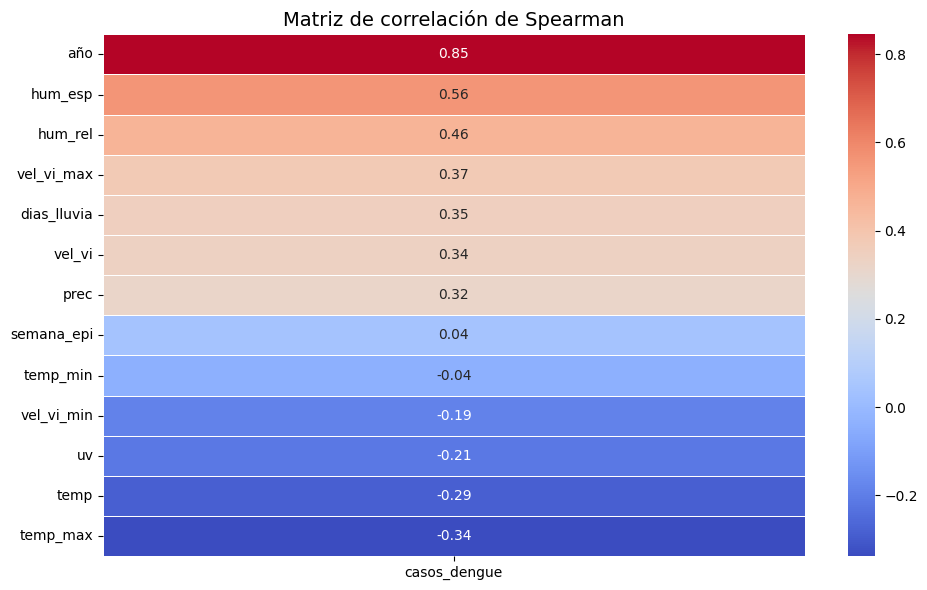

In [182]:
# Crear el mapa de calor
plt.figure(figsize=(10,6))
sns.heatmap(corr_spearman[['casos_dengue']].sort_values(by='casos_dengue', ascending=False)[1:], 
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)
plt.title('Matriz de correlación de Spearman', fontsize=14)
plt.tight_layout()
plt.show()

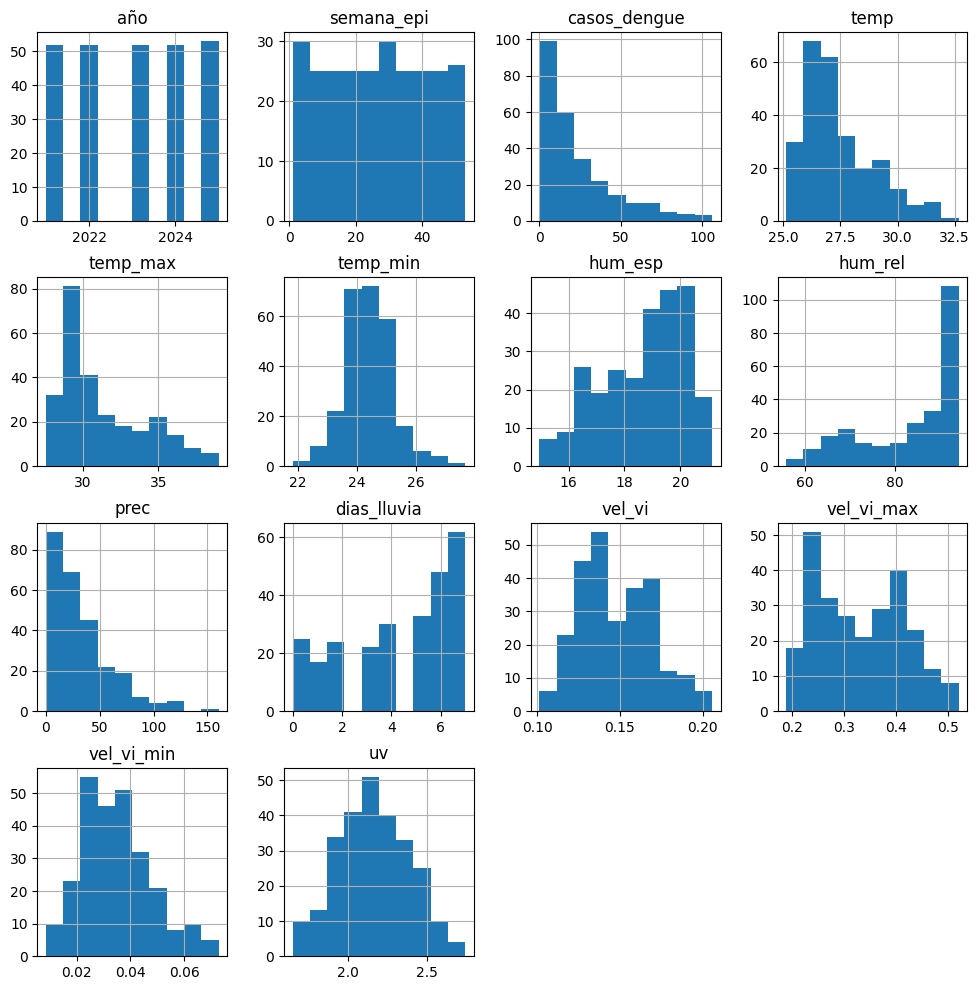

In [183]:
df_final_fusionado.hist(figsize=(12,12))
plt.savefig("histogramas.png")
plt.show()

In [184]:
df_final_fusionado.columns

Index(['año', 'semana_epi', 'casos_dengue', 'temp', 'temp_max', 'temp_min',
       'hum_esp', 'hum_rel', 'prec', 'dias_lluvia', 'vel_vi', 'vel_vi_max',
       'vel_vi_min', 'uv'],
      dtype='object')

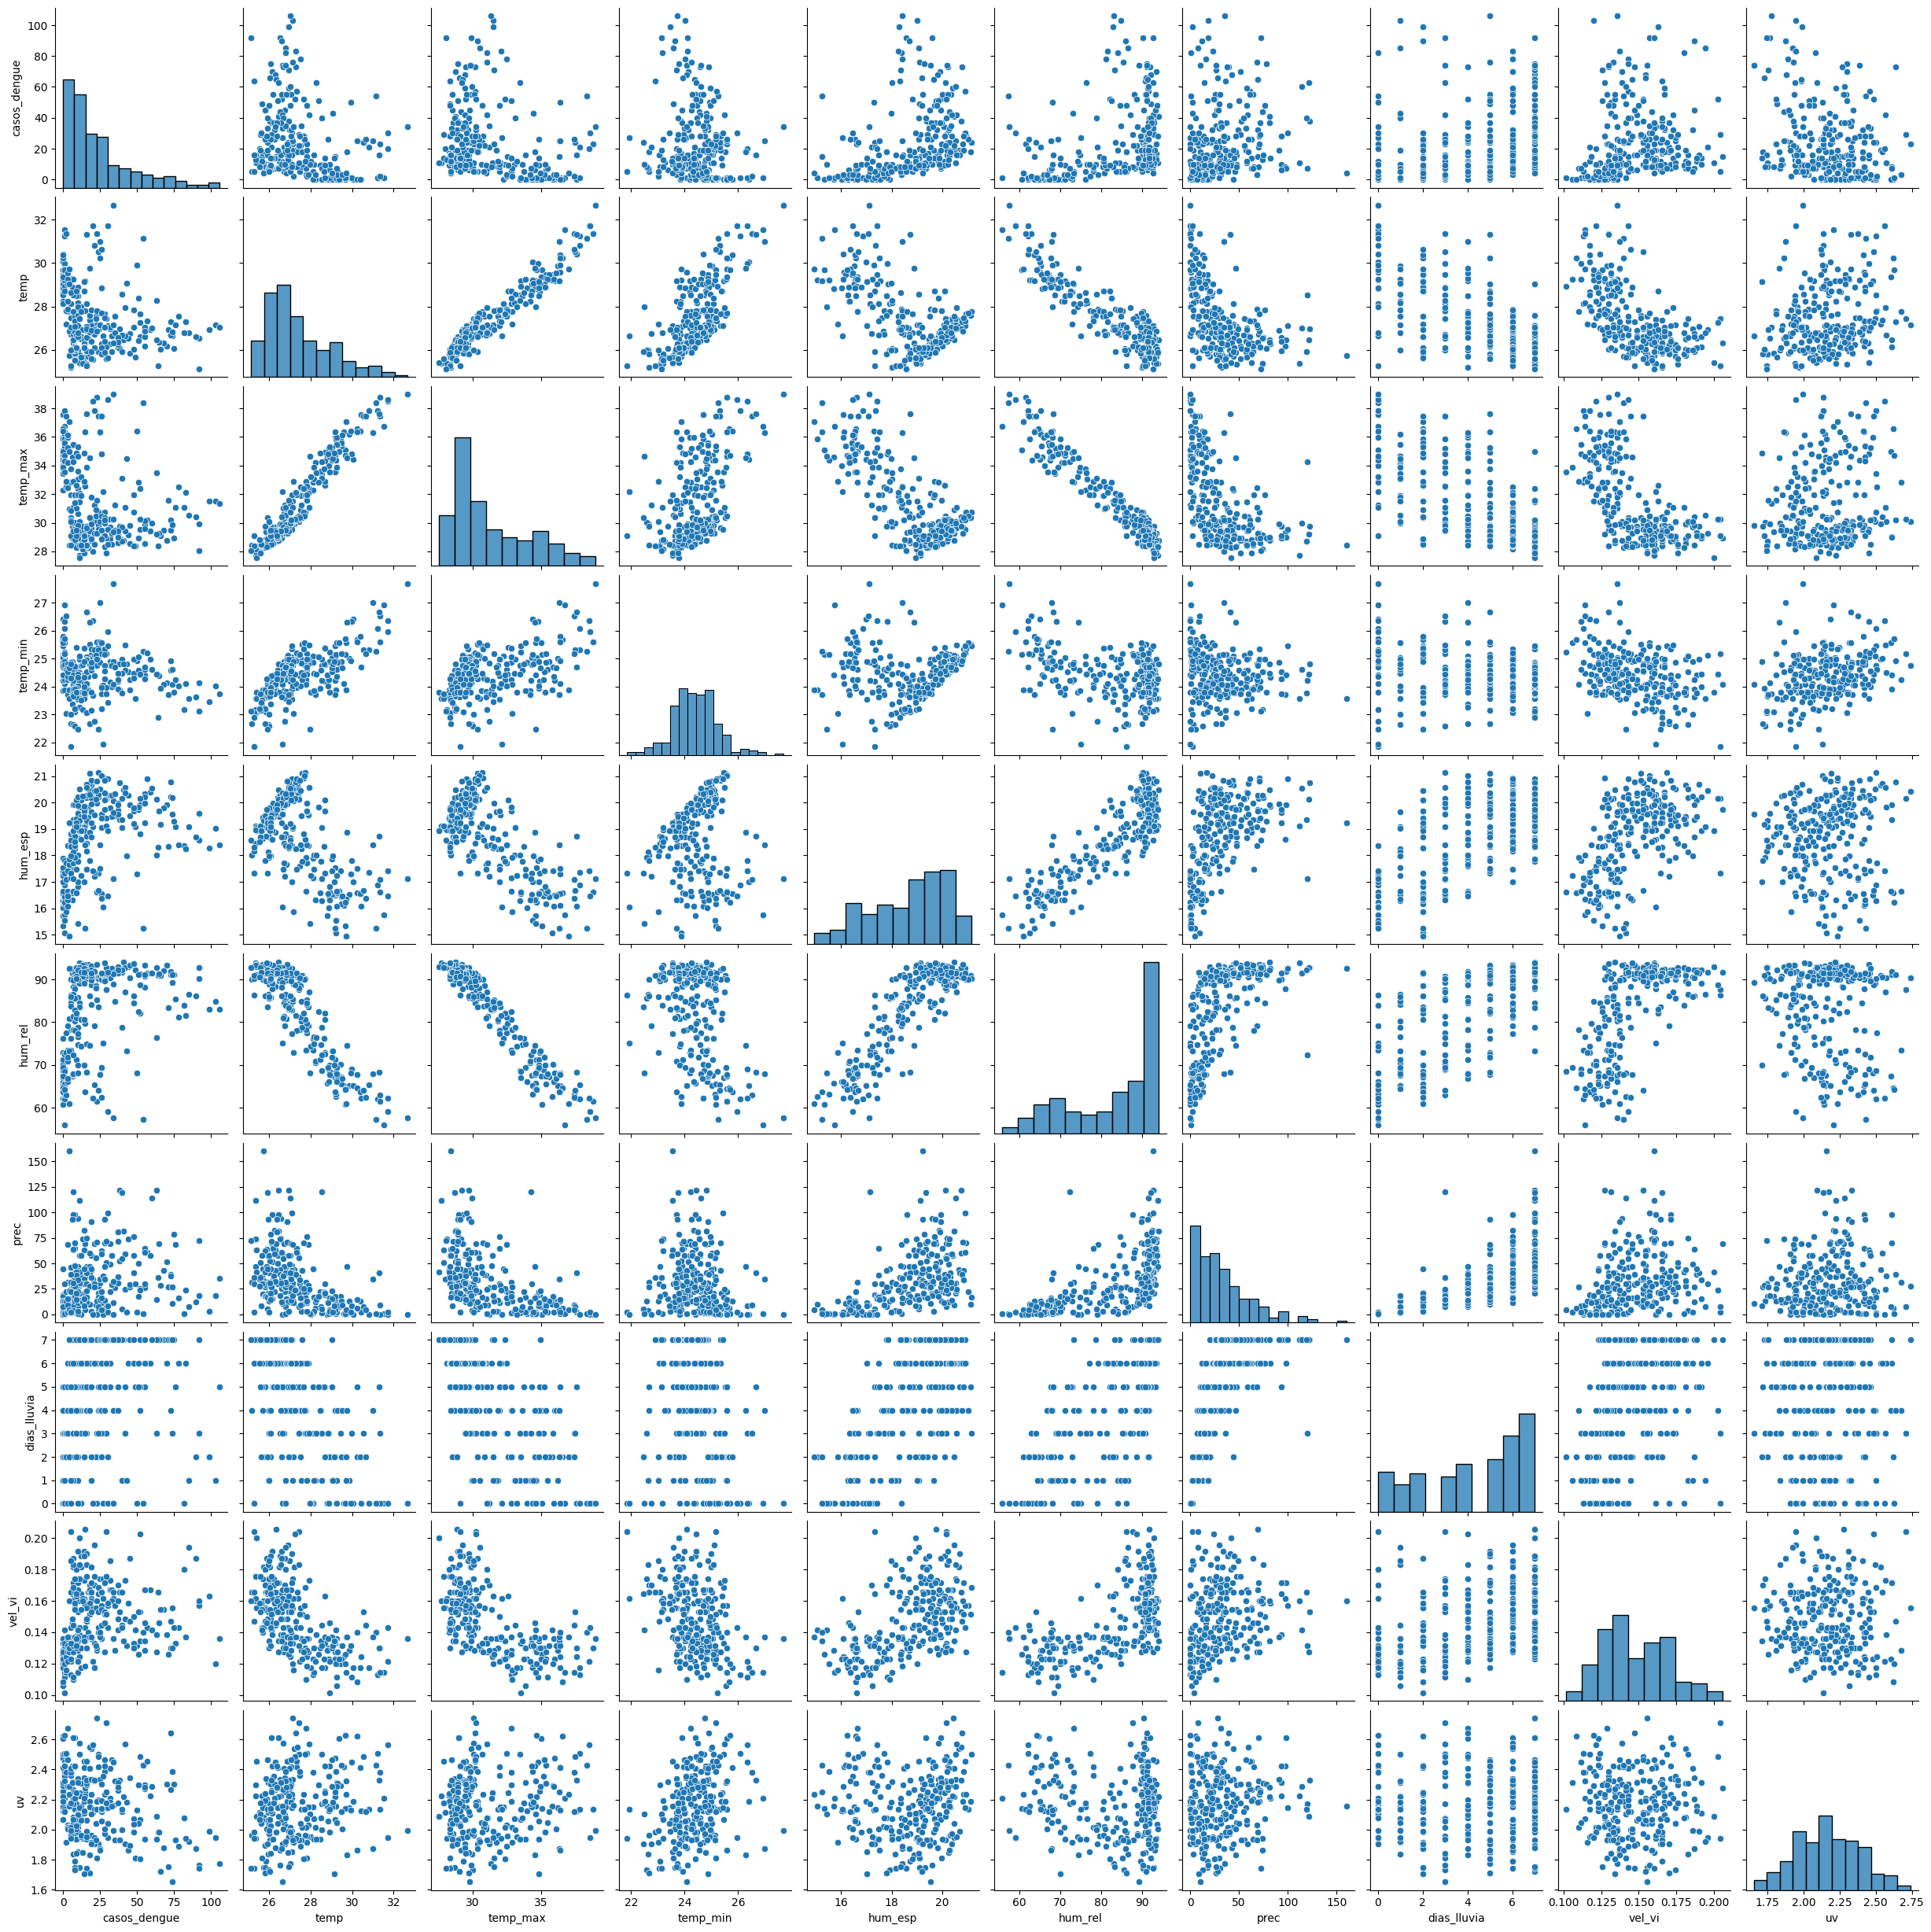

In [186]:
# graficar en una matriz todos los scaterter plots entre las variables numéricas
import seaborn as sns   
sns.pairplot(df_final_fusionado[['casos_dengue', 'temp', 'temp_max',
       'temp_min', 'hum_esp', 'hum_rel', 'prec', 'dias_lluvia', 'vel_vi',
       'uv']])
plt.savefig("scatter_matrix.png")
plt.show()

In [199]:
import pandas as pd
import matplotlib.pyplot as plt

# Variable a analizar
variable_clima = 'prec'
max_lags = 12
correlaciones_lag = []

for lag in range(max_lags + 1):
    # Creamos la versión rezagada de la variable
    variable_lagged = df_final_fusionado[variable_clima].shift(lag)
    
    # Calculamos Spearman entre casos actuales y clima del pasado
    # .corr() con method='spearman'
    corr = df_final_fusionado['casos_dengue'].corr(variable_lagged, method='spearman')
    correlaciones_lag.append(corr)

# Crear DataFrame para visualizar
df_lags = pd.DataFrame({'Semana de Rezago': range(max_lags + 1), 'Correlación': correlaciones_lag})

C:\Users\usuario1\AppData\Local\Temp\ipykernel_2180\737723710.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Semana de Rezago', y='Correlación', data=df_lags, palette='viridis')


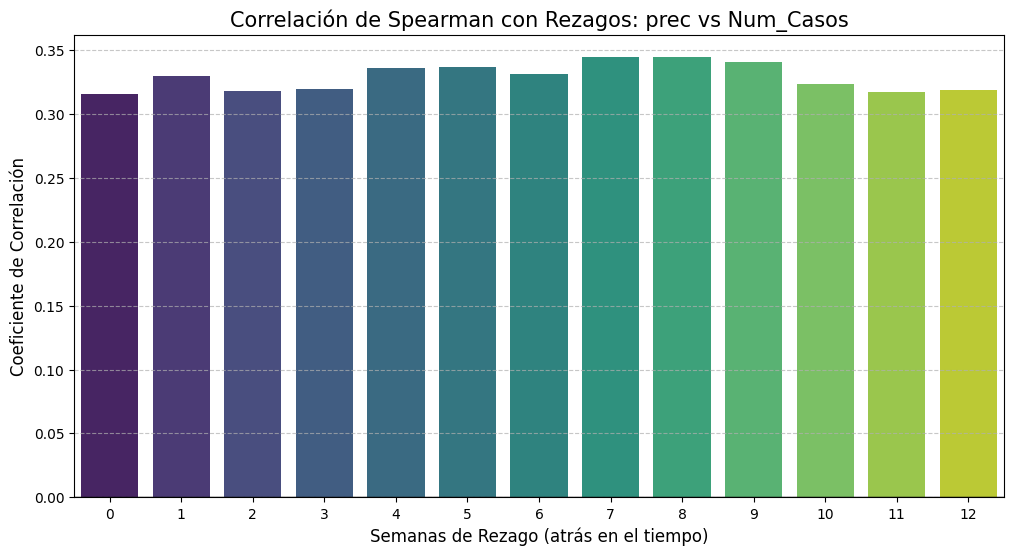

In [200]:
import seaborn as sns

# Configurar el estilo del gráfico
plt.figure(figsize=(12, 6))
sns.barplot(x='Semana de Rezago', y='Correlación', data=df_lags, palette='viridis')

# Añadir una línea de referencia en 0
plt.axhline(0, color='black', linestyle='-', linewidth=1)

# Títulos y etiquetas
plt.title(f'Correlación de Spearman con Rezagos: {variable_clima} vs Num_Casos', fontsize=15)
plt.xlabel('Semanas de Rezago (atrás en el tiempo)', fontsize=12)
plt.ylabel('Coeficiente de Correlación', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

## Rezagos

In [189]:
df_rezagos = df_final_fusionado.copy()

variables_climaticas = [
    'temp', 'temp_max', 'temp_min', 'hum_esp', 'hum_rel',
    'prec', 'dias_lluvia', 'vel_vi', 'vel_vi_max', 'vel_vi_min', 'uv'
]

# Crear rezagos (1 a 12 semanas)
for var in variables_climaticas:
    for lag in range(1, 13):
        df_rezagos[f'{var}_lag{lag}'] = df_rezagos[var].shift(lag)

C:\Users\usuario1\AppData\Local\Temp\ipykernel_2180\3544174273.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_rezagos[f'{var}_lag{lag}'] = df_rezagos[var].shift(lag)
C:\Users\usuario1\AppData\Local\Temp\ipykernel_2180\3544174273.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_rezagos[f'{var}_lag{lag}'] = df_rezagos[var].shift(lag)
C:\Users\usuario1\AppData\Local\Temp\ipykernel_2180\3544174273.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many tim

In [190]:
df_lags = df_rezagos.dropna()

In [191]:
correlaciones = {}

for var in variables_climaticas:
    for lag in range(1, 13):
        nombre = f'{var}_lag{lag}'
        correlaciones[nombre] = df_lags['casos_dengue'].corr(df_lags[nombre])

# Convertir a DataFrame
df_corr = pd.DataFrame.from_dict(correlaciones, orient='index', columns=['correlacion'])

In [195]:
df_corr = df_corr.sort_values(by='correlacion', key=abs, ascending=False)

df_corr.head(20)

,correlacion
hum_esp_lag11,0.423886
hum_esp_lag9,0.423395
hum_esp_lag6,0.421342
hum_esp_lag8,0.418088
hum_esp_lag12,0.417631
hum_esp_lag10,0.416633
hum_esp_lag7,0.416566
hum_esp_lag5,0.403364
hum_esp_lag4,0.391457
hum_esp_lag3,0.381030
